<a href="https://colab.research.google.com/github/ZukhrufianAbdullah/PCVK_Ganjil_2026/blob/main/Week-07/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## D. Praktikum Filter
### D.2.b Akses Drive dan import library

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('Bukan di Google Colab / Drive tidak di-mount:', e)

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math

BASE = '/content/drive/MyDrive/PCVK/Gambar'

def load_image(path, fallback):
    """Baca citra (BGR). Jika file tidak ada, pakai citra contoh scikit-image."""
    img = cv.imread(path)
    if img is None:
        print(f'[info] {path} tidak ditemukan -> memakai citra contoh')
        from skimage import data
        img = cv.cvtColor(getattr(data, fallback)(), cv.COLOR_RGB2BGR)
    return img

def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (im, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(im.shape) == 2:                       # grayscale
            plt.imshow(im, cmap='gray', vmin=0, vmax=255)
        else:                                        # color (BGR)
            plt.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.show()

def to_uint8(x):
    return np.clip(x, 0, 255).astype(np.uint8)

### D.2.c Fungsi konvolusi tanpa library

Fungsi `convolution2d(image, kernel, stride, padding)` mengikuti algoritma Bagian C: hasil di setiap posisi adalah **jumlah perkalian tiap elemen kernel dengan piksel tetangga** (pseudocode `z(x,y) = z(x,y) + H(k1,k2)*Img_pixel(x+k1, y+k2)`).

Parameter:
1. `image` – citra masukan (grayscale 2D, atau berwarna 3D: tiap kanal diproses sendiri),
2. `kernel` – matriks kernel,
3. `stride` – besar pergeseran kernel,
4. `padding` – jumlah piksel tambahan di tiap sisi (solusi masalah *border / menggantung*). Nilai pad diisi **0** (solusi 3 modul, Gambar 6) atau, dengan `pad_mode='edge'`, **duplikasi piksel tepi** (solusi 2 modul, Gambar 5).

Ukuran keluaran: `(H + 2*padding - kh) // stride + 1`. Untuk kernel 3x3 dan hasil berukuran sama dengan citra, pakai `padding = 1` (secara umum `kernel_size // 2`).

Dua versi dibuat:
- `convolution2d_naive` – 4 loop bersarang persis seperti pseudocode (lambat, untuk verifikasi pada contoh kecil),
- `convolution2d` – kelompok loop yang sama tetapi loop `x,y` dikerjakan sekaligus dengan slicing NumPy (jauh lebih cepat, hasilnya identik). Tidak ada fungsi konvolusi library (`cv.filter2D`, `scipy.signal`, dll.) yang dipakai.

*Catatan:* sesuai pseudocode modul, kernel **tidak dibalik** (secara matematis ini korelasi). Untuk kernel simetris hasilnya sama dengan konvolusi; untuk kernel asimetris (Emboss, Sobel) hanya arah efeknya yang terbalik.

In [3]:
def pad_image(image, padding, pad_mode='constant'):
    if padding <= 0:
        return image
    pw = ((padding, padding), (padding, padding)) + ((0, 0),) * (image.ndim - 2)
    return np.pad(image, pw, mode=pad_mode)          # 'constant' -> 0, 'edge' -> duplikasi tepi


def convolution2d_naive(image, kernel, stride=1, padding=0, pad_mode='constant'):
    """Versi 4 loop persis seperti pseudocode modul (grayscale saja)."""
    image = pad_image(np.asarray(image, dtype=np.float64), padding, pad_mode)
    kernel = np.asarray(kernel, dtype=np.float64)
    kh, kw = kernel.shape
    out_h = (image.shape[0] - kh) // stride + 1
    out_w = (image.shape[1] - kw) // stride + 1
    z = np.zeros((out_h, out_w))
    for x in range(out_h):
        for y in range(out_w):
            for k1 in range(kh):
                for k2 in range(kw):
                    z[x, y] += kernel[k1, k2] * image[x * stride + k1, y * stride + k2]
    return z


def convolution2d(image, kernel, stride=1, padding=0, pad_mode='constant'):
    """Konvolusi 2D tanpa library konvolusi.
    image  : array 2D (grayscale) atau 3D (H, W, C)
    kernel : array 2D
    stride : besar pergeseran kernel
    padding: jumlah piksel pad di tiap sisi
    return : array float64 hasil konvolusi (belum di-clip ke 0..255)
    """
    image = np.asarray(image, dtype=np.float64)
    kernel = np.asarray(kernel, dtype=np.float64)
    if image.ndim == 3:                                   # citra berwarna: per kanal
        return np.dstack([convolution2d(image[:, :, c], kernel, stride, padding, pad_mode)
                          for c in range(image.shape[2])])
    kh, kw = kernel.shape
    image = pad_image(image, padding, pad_mode)
    out_h = (image.shape[0] - kh) // stride + 1
    out_w = (image.shape[1] - kw) // stride + 1
    z = np.zeros((out_h, out_w))
    for k1 in range(kh):                                  # z(x,y) += H(k1,k2) * Img(x+k1, y+k2)
        for k2 in range(kw):
            patch = image[k1:k1 + (out_h - 1) * stride + 1:stride,
                          k2:k2 + (out_w - 1) * stride + 1:stride]
            z += kernel[k1, k2] * patch
    return z

**Verifikasi dengan contoh matriks 5x5 pada modul** (kernel Laplacian `[[0,-1,0],[-1,4,-1],[0,-1,0]]`, tanpa padding, tepi diabaikan):

In [4]:
f = np.array([[4, 4, 3, 5, 4],
              [6, 6, 5, 5, 2],
              [5, 6, 6, 6, 2],
              [6, 7, 5, 5, 3],
              [3, 5, 2, 4, 4]])
k = np.array([[ 0, -1,  0],
              [-1,  4, -1],
              [ 0, -1,  0]])

print('Naive   :\n', convolution2d_naive(f, k, 1, 0).astype(int))
print('Vektor  :\n', convolution2d(f, k, 1, 0).astype(int))
print('Sama?   :', np.allclose(convolution2d_naive(f, k), convolution2d(f, k)))

Naive   :
 [[3 0 2]
 [0 2 6]
 [6 0 2]]
Vektor  :
 [[3 0 2]
 [0 2 6]
 [6 0 2]]
Sama?   : True


Hasil perhitungan: baris pertama `3 0 2`, sesuai dengan langkah 1–3 pada modul (3, 0, 2). Baris kedua `0 2 6` dan baris ketiga `6 0 2` juga sama dengan modul. Pada gambar langkah 4(ii)–5 dan Gambar 4 modul, baris pertama tertulis `4 0 8`. Itu tidak cocok dengan perhitungan langkah 1–3 di modul sendiri (3, 0, 2), jadi kemungkinan salah ketik di modul.

### D.2.d Load citra dan ubah menjadi keabuan

(666, 666, 3) (666, 666)


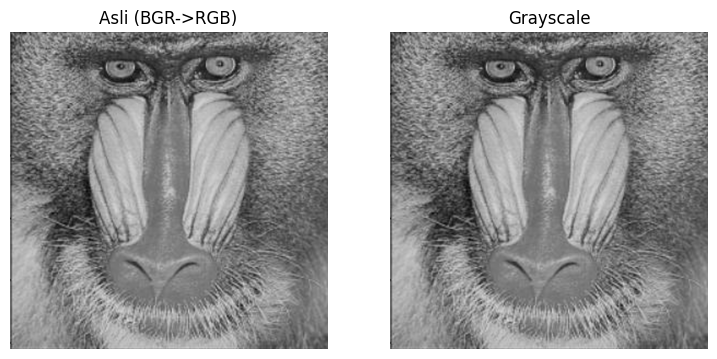

In [5]:
img = cv.imread('/content/drive/MyDrive/PCVK/Gambar/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
print(img.shape, img_gray.shape)
show_side_by_side([img, img_gray], ['Asli (BGR->RGB)', 'Grayscale'], figsize=(9, 4.5))

### D.2.e – f  Menentukan kernel dan memanggil fungsi konvolusi

Ukuran citra : (666, 666)
Ukuran hasil : (668, 668) (padding=2 pada kernel 3x3 menambah 2 piksel per dimensi)
padding = 1  : (666, 666)


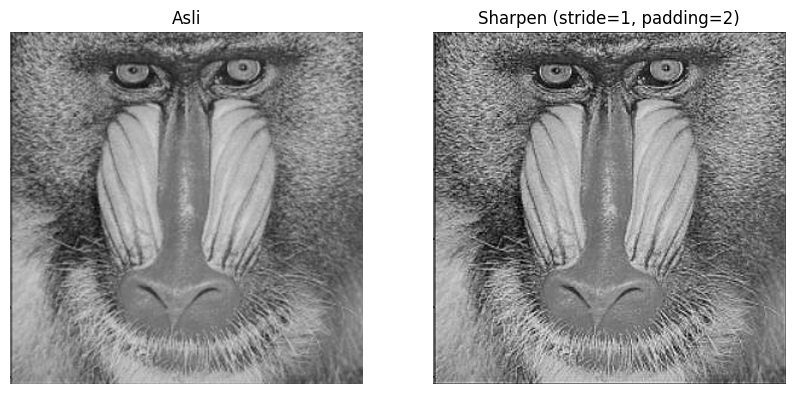

In [6]:
# image sharpen
kernel_sharpen = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

# contoh pemanggilan seperti di modul: stride = 1, padding = 2
hasil = convolution2d(img_gray, kernel_sharpen, 1, 2)
print('Ukuran citra :', img_gray.shape)
print('Ukuran hasil :', hasil.shape, '(padding=2 pada kernel 3x3 menambah 2 piksel per dimensi)')

# padding = 1 -> ukuran hasil sama dengan citra asli
hasil_same = convolution2d(img_gray, kernel_sharpen, 1, 1)
print('padding = 1  :', hasil_same.shape)

show_side_by_side([img_gray, to_uint8(hasil)], ['Asli', 'Sharpen (stride=1, padding=2)'], figsize=(10, 5))

### D.3 Image filter: Average, Low Pass, High Pass, dan filter pada tabel modul

Seluruh filter memakai fungsi `convolution2d` buatan sendiri (padding = `kernel_size // 2` agar ukuran hasil tetap).

In [7]:
# ---------- Kernel ----------
kernels = {}

# Filter dasar (Bagian C.3)
kernels['Average Filter 3x3'] = np.ones((3, 3)) / 9
kernels['Low Pass Filter'] = np.array([[1, 1, 1],
                                       [1, 4, 1],
                                       [1, 1, 1]]) / 12
kernels['High Pass Filter'] = np.array([[-1, 0, 1],
                                        [-1, 0, 3],
                                        [-3, 0, 1]])        # sesuai modul

# Tabel D.3
kernels['Sharpen'] = np.array([[ 0, -1,  0],
                               [-1,  5, -1],
                               [ 0, -1,  0]])
kernels['Emboss'] = np.array([[-2, -1, 0],
                              [-1,  1, 1],
                              [ 0,  1, 2]])
kernels['Left Sobel Edge Detection'] = np.array([[1, 0, -1],
                                                 [2, 0, -2],
                                                 [1, 0, -1]])
kernels['Canny Edge Detection'] = np.array([[-1, -1, -1],       # (kernel Laplacian 8-tetangga sesuai modul)
                                            [-1,  8, -1],
                                            [-1, -1, -1]])

# Gaussian 21x21 (kode dari modul)
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)      # hanya untuk membangkitkan kernel
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()
kernels['21x21 Gaussian Blur'] = gauss_kernel

for nama, k in kernels.items():
    print(f'{nama:28s} ukuran {k.shape}  jumlah elemen = {k.sum():.3f}')

Average Filter 3x3           ukuran (3, 3)  jumlah elemen = 1.000
Low Pass Filter              ukuran (3, 3)  jumlah elemen = 1.000
High Pass Filter             ukuran (3, 3)  jumlah elemen = 0.000
Sharpen                      ukuran (3, 3)  jumlah elemen = 1.000
Emboss                       ukuran (3, 3)  jumlah elemen = 1.000
Left Sobel Edge Detection    ukuran (3, 3)  jumlah elemen = 0.000
Canny Edge Detection         ukuran (3, 3)  jumlah elemen = 0.000
21x21 Gaussian Blur          ukuran (21, 21)  jumlah elemen = 1.000


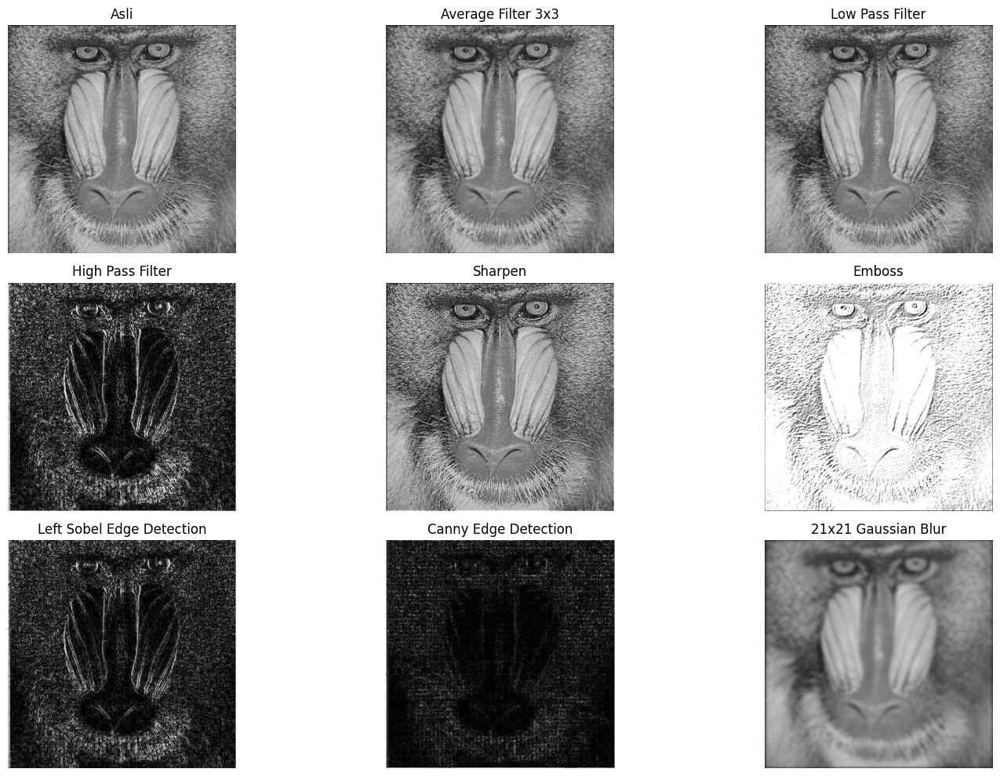

In [8]:
# ---------- Terapkan ----------
hasil = {}
for nama, k in kernels.items():
    out = convolution2d(img_gray, k, stride=1, padding=k.shape[0] // 2)
    if nama == 'Emboss':
        out = out + 128                       # geser ke abu-abu tengah agar efek timbul terlihat
    elif nama in ('Left Sobel Edge Detection', 'Canny Edge Detection', 'High Pass Filter'):
        out = np.abs(out)                     # tampilkan besar respons tepi
    hasil[nama] = to_uint8(out)

# Tampilkan dalam grid
nama_list = ['Asli'] + list(hasil.keys())
img_list = [img_gray] + [hasil[n] for n in hasil]
plt.figure(figsize=(16, 10))
for i, (n, im) in enumerate(zip(nama_list, img_list)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(n)
    plt.axis('off')
plt.tight_layout()
plt.show()

**Pengamatan singkat**

| Filter | Efek |
|---|---|
| Average 3x3, Low Pass | Citra jadi lebih halus (frekuensi tinggi ditekan, jumlah elemen = 1 sehingga kecerahan tetap). Low Pass memberi bobot lebih besar pada piksel tengah (4/12), jadi blurnya lebih ringan. |
| High Pass | Jumlah elemen kernel = 0 sehingga area datar jadi gelap dan hanya perubahan intensitas yang tersisa. |
| Sharpen | Jumlah elemen = 1, kecerahan tetap dan tepi menjadi lebih tegas. |
| Emboss | Tepi pada arah tertentu (negatif ke positif) tampak timbul. Nilai 128 ditambahkan agar area datar menjadi abu-abu. |
| Left Sobel | Hanya tepi vertikal (perubahan horizontal) yang menyala. |
| "Canny" (Laplacian 8) | Semua tepi/detail halus ke segala arah. Ini sebenarnya kernel Laplacian, bukan algoritma Canny yang utuh (lihat Percobaan 1). |
| Gaussian 21x21 | Blur kuat, bobot menurun halus dari tengah. |

**Verifikasi:** hasil `convolution2d` buatan sendiri dibandingkan dengan `cv.filter2D` (hanya untuk pengecekan). Padding nol dipakai di kedua sisi (`BORDER_CONSTANT`), seharusnya selisihnya mendekati 0.

In [9]:
for nama, k in kernels.items():
    mine = convolution2d(img_gray, k, 1, k.shape[0] // 2)
    ref = cv.filter2D(img_gray.astype(np.float64), -1, k, borderType=cv.BORDER_CONSTANT)
    print(f'{nama:28s} selisih maksimum = {np.abs(mine - ref).max():.2e}')

Average Filter 3x3           selisih maksimum = 0.00e+00
Low Pass Filter              selisih maksimum = 0.00e+00
High Pass Filter             selisih maksimum = 0.00e+00
Sharpen                      selisih maksimum = 0.00e+00
Emboss                       selisih maksimum = 0.00e+00
Left Sobel Edge Detection    selisih maksimum = 0.00e+00
Canny Edge Detection         selisih maksimum = 0.00e+00
21x21 Gaussian Blur          selisih maksimum = 6.25e-13


## E. Filter Library dan Filter Modern
### Percobaan 1 – Gaussian, Sharpen, dan Canny dengan library OpenCV (`filter2D`)

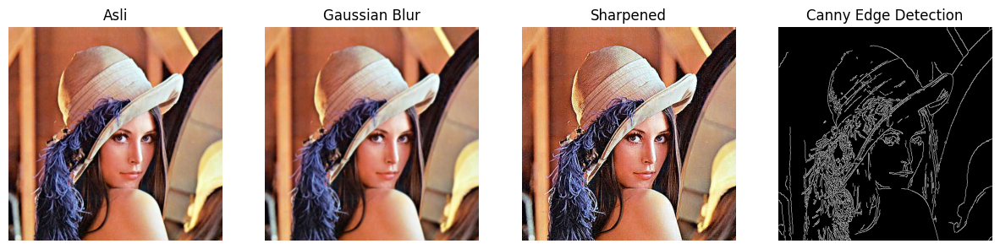

In [10]:
img = cv.imread("/content/drive/MyDrive/PCVK/Gambar/Lenna.jpeg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7, 7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, sharpened, edges],
                  ['Asli', 'Gaussian Blur', 'Sharpened', 'Canny Edge Detection'])

Gaussian Blur menghaluskan citra, `filter2D` dengan kernel sharpen menajamkan, dan `cv.Canny` menghasilkan garis tepi tipis biner. Canny memakai beberapa tahap (Gaussian smoothing, gradien Sobel, non-maximum suppression, dan hysteresis thresholding), sehingga hasilnya jauh lebih bersih daripada satu kernel Laplacian.

### Percobaan 2 – Filter modern: Bilateral dan Edge Preserving (alternatif Guided Filter)

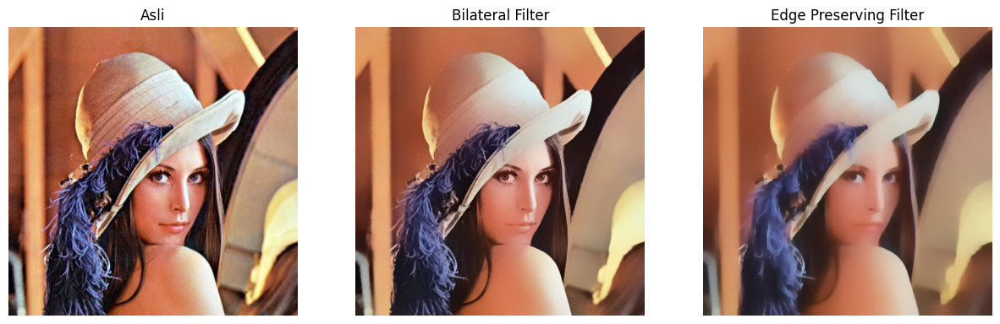

In [11]:
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ['Asli', 'Bilateral Filter', 'Edge Preserving Filter'])

Kedua filter menghaluskan area datar (kulit, latar) sambil mempertahankan tepi (kontur wajah, topi). Gaussian blur biasa mengaburkan tepi karena bobotnya hanya bergantung pada jarak. Bilateral juga mempertimbangkan selisih intensitas warna, sehingga piksel di seberang tepi hampir tidak memengaruhi hasil. Kekurangannya komputasinya lebih lambat.

### Percobaan 3 – Filtering pada CNN (Feature Map)
Lapisan konvolusi `Conv2d(1, 4, kernel_size=3, padding=1)` memiliki 4 kernel 3x3 yang **bobotnya diinisialisasi acak** setiap model dibuat. Sel di bawah dijalankan 3 kali, dan tiap kali `SimpleCNN()` dibuat ulang sehingga kernel yang didapat berbeda.

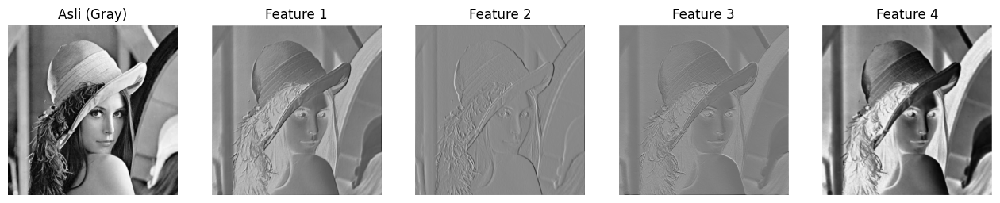

Run 1 - kernel Feature 1:
 [[-0.31 -0.33  0.13]
 [-0.05  0.12 -0.03]
 [-0.14  0.02  0.23]]


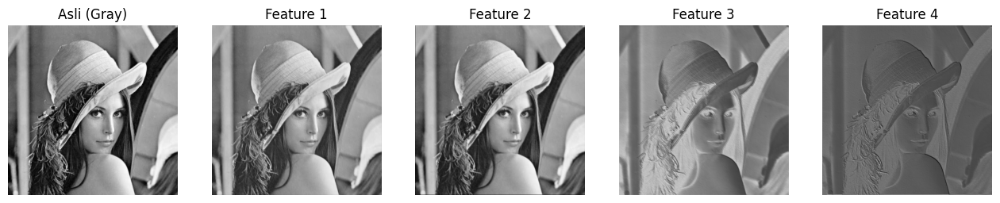

Run 2 - kernel Feature 1:
 [[ 0.16  0.2  -0.12]
 [-0.15  0.29  0.21]
 [-0.11  0.18 -0.02]]


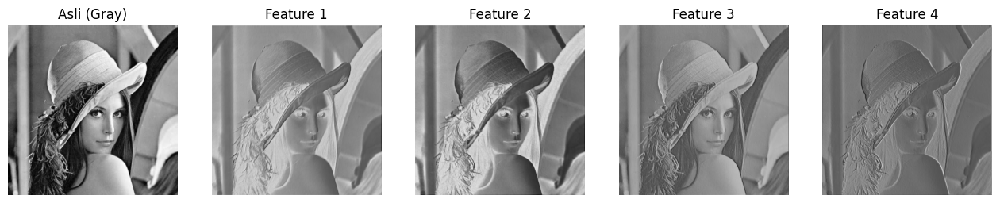

Run 3 - kernel Feature 1:
 [[-0.04 -0.33 -0.06]
 [ 0.05 -0.24  0.18]
 [-0.14 -0.24  0.28]]


In [12]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

# Ubah gambar ke tensor (1, 1, H, W)
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

for run in range(3):                                   # jalankan beberapa kali
    model = SimpleCNN()
    with torch.no_grad():
        features = model(img_tensor)

    feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
    # normalisasi tiap feature map ke 0..255 agar bisa ditampilkan
    fm_show = [to_uint8(255 * (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)) for fm in feature_maps]
    show_side_by_side([img_gray] + fm_show,
                      ['Asli (Gray)'] + [f'Feature {i+1}' for i in range(len(fm_show))],
                      figsize=(16, 3.5))
    print(f'Run {run+1} - kernel Feature 1:\n', model.conv1.weight[0, 0].detach().numpy().round(2))

**Kesimpulan Percobaan 3**

1. **Setiap kali dijalankan, hasilnya berbeda.** Bobot kernel awal acak dan belum dilatih, jadi tiap feature map hasilnya acak. Ada yang mirip citra asli yang dicerahkan atau digelapkan, ada yang menonjolkan tepi/tekstur (seperti kernel high pass atau Sobel), ada yang menghaluskan (seperti blur).
2. **Ukuran feature map sama dengan citra** karena `padding=1` dan `stride=1` untuk kernel 3x3. Operasinya sama dengan konvolusi di Bagian D, ditambah bias.
3. **Perbedaan dengan filter tradisional:** pada filter tradisional, kernel dirancang manusia (sharpen, Sobel, Gaussian). Pada CNN, kernel adalah *parameter yang dipelajari* lewat training sehingga CNN menemukan sendiri filter yang berguna untuk tugasnya (tepi, tekstur, lalu pola kompleks di lapisan yang lebih dalam).
4. Satu lapis konvolusi dengan banyak kernel menghasilkan banyak "pandangan" berbeda dari citra yang sama, yang menjadi masukan lapisan berikutnya.

### Percobaan 4 – Efek Beauty dan Vintage (kombinasi filter tradisional)
Beauty = Bilateral (haluskan kulit) → Unsharp masking (pertajam) → kontras & brightness.
Vintage = Sepia → Vignette (Gaussian mask) → Grain (noise acak).

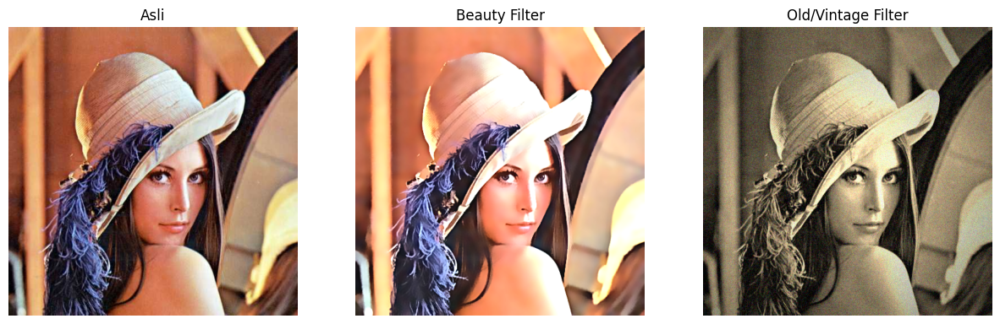

In [13]:
# =====================
# 1. Beauty Filter
# =====================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2   # contrast
beta = 15     # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# =====================
# 2. Old/Vintage Filter
# =====================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:, :, i] = vignette[:, :, i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img], ['Asli', 'Beauty Filter', 'Old/Vintage Filter'])

### Percobaan 5 – Filter Anime / Cartoon

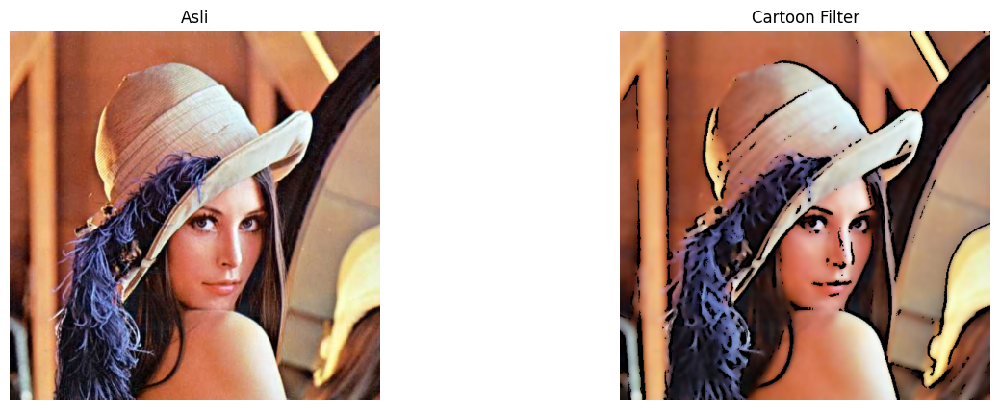

In [14]:
# Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ['Asli', 'Cartoon Filter'])

### Percobaan 6 – Filter Malam

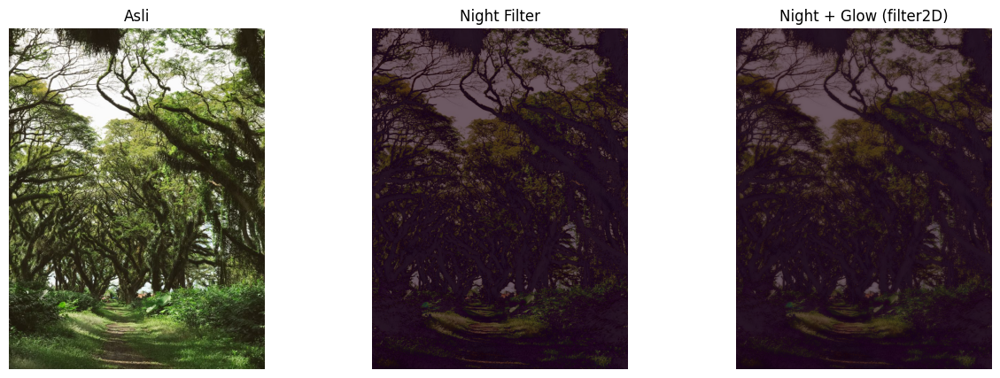

In [15]:
# Night Filter
img_scene = cv.imread('/content/drive/MyDrive/PCVK/Gambar/djawatan.jpg')

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img_scene, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))    # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img_scene, night, night_glow],
                  ['Asli', 'Night Filter', 'Night + Glow (filter2D)'])

### Percobaan 7 – Filter Pagi dan Pagi + Kabut

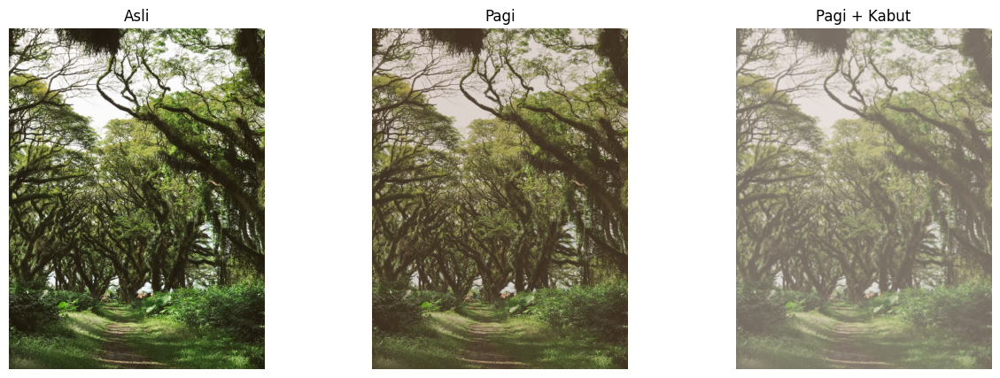

In [16]:
# Filter Suasana pagi dan Kabut
# Step 1: Kurangi kontras & cerahkan
alpha = 0.9   # contrast
beta = 20     # brightness
soft = cv.convertScaleAbs(img_scene, alpha=alpha, beta=beta)

# Step 2: Tambahkan warm tone (kemerahan / oranye)
warm_tint = np.full_like(soft, (40, 70, 120))   # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T                       # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img_scene, pagi, kabut], ['Asli', 'Pagi', 'Pagi + Kabut'])

---
## Tugas Praktikum
### Tugas 1 – Analisis: Mean Filter vs Median Filter pada noise Salt & Pepper

**a.** Tambahkan noise salt & pepper ke citra grayscale.

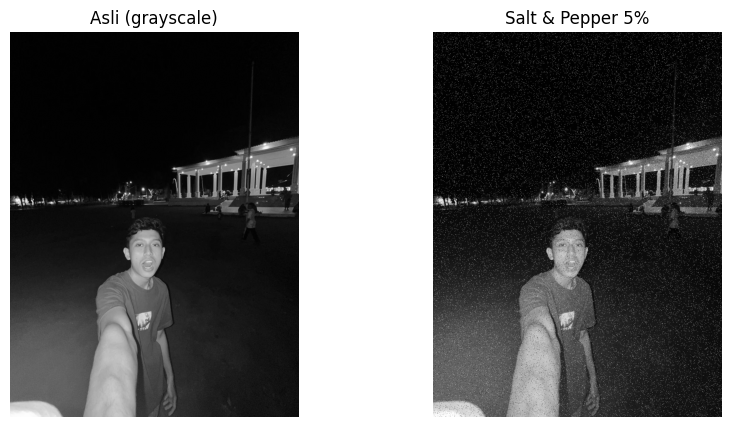

In [20]:
gray = cv.cvtColor(load_image(BASE + '/fian.jpg', 'fian'), cv.COLOR_BGR2GRAY)

def add_salt_pepper(image, amount=0.05, salt_ratio=0.5, seed=42):
    """amount = proporsi piksel yang terkena noise."""
    rng = np.random.default_rng(seed)
    noisy = image.copy()
    r = rng.random(image.shape)
    noisy[r < amount * salt_ratio] = 255                         # salt (putih)
    noisy[(r >= amount * salt_ratio) & (r < amount)] = 0         # pepper (hitam)
    return noisy

noisy = add_salt_pepper(gray, amount=0.05)
show_side_by_side([gray, noisy], ['Asli (grayscale)', 'Salt & Pepper 5%'], figsize=(10, 5))

**b.** Terapkan Mean Filter (3x3) dan Median Filter (3x3). Mean memakai `convolution2d` buatan sendiri; Median dibuat dengan mengurutkan 9 tetangga lalu mengambil nilai tengah (dicek dengan `cv.medianBlur`).

Sama dengan cv.medianBlur? -> True
                     MSE   PSNR (dB)
Noisy             1338.4       16.87
Mean 3x3           186.1       25.43
Median 3x3           9.7       38.27


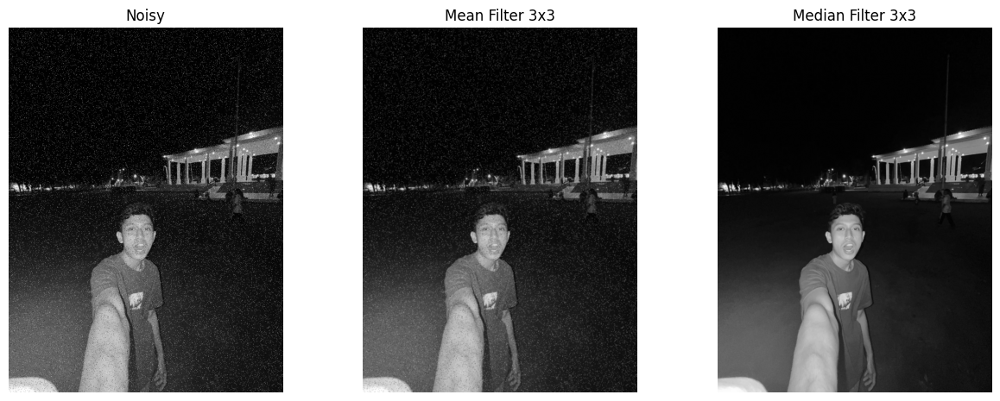

In [21]:
# Mean filter 3x3 (konvolusi, tepi diisi duplikasi piksel tepi)
mean_kernel = np.ones((3, 3)) / 9
mean_f = to_uint8(np.round(convolution2d(noisy, mean_kernel, 1, 1, pad_mode='edge')))

# Median filter 3x3 (non-linear: ambil nilai tengah dari 9 piksel)
def median_filter(image, size=3):
    p = size // 2
    padded = np.pad(image, p, mode='edge')
    H, W = image.shape
    stack = np.stack([padded[i:i + H, j:j + W] for i in range(size) for j in range(size)], axis=0)
    return np.median(stack, axis=0).astype(np.uint8)

median_f = median_filter(noisy, 3)
print('Sama dengan cv.medianBlur? ->', np.array_equal(median_f, cv.medianBlur(noisy, 3)))

def mse(a, b): return np.mean((a.astype(float) - b.astype(float)) ** 2)
def psnr(a, b): return 10 * np.log10(255 ** 2 / mse(a, b))

print(f'{"":14s}{"MSE":>10s}{"PSNR (dB)":>12s}')
for n, im in [('Noisy', noisy), ('Mean 3x3', mean_f), ('Median 3x3', median_f)]:
    print(f'{n:14s}{mse(gray, im):10.1f}{psnr(gray, im):12.2f}')

show_side_by_side([noisy, mean_f, median_f], ['Noisy', 'Mean Filter 3x3', 'Median Filter 3x3'], figsize=(15, 5.5))

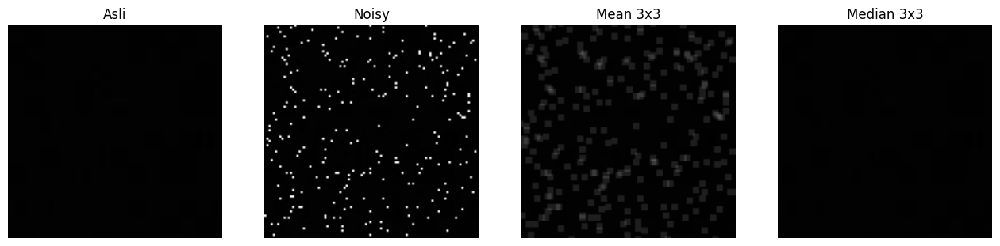

Jendela:
 [[100 102 101]
 [ 99 255 100]
 [101  98 100]]
Mean   = 117.3 (piksel tengah ikut terseret naik oleh outlier 255)
Median = 100.0 (outlier 255 terbuang)


In [22]:
# Zoom pada satu area agar perbedaan terlihat jelas
y0, y1, x0, x1 = 150, 250, 200, 300
show_side_by_side([gray[y0:y1, x0:x1], noisy[y0:y1, x0:x1], mean_f[y0:y1, x0:x1], median_f[y0:y1, x0:x1]],
                  ['Asli', 'Noisy', 'Mean 3x3', 'Median 3x3'], figsize=(16, 4.5))

# Contoh perhitungan satu jendela 3x3 dengan 1 piksel "salt"
w = np.array([[100, 102, 101],
              [ 99, 255, 100],
              [101,  98, 100]])
print('Jendela:\n', w)
print('Mean   =', w.mean().round(1), '(piksel tengah ikut terseret naik oleh outlier 255)')
print('Median =', np.median(w), '(outlier 255 terbuang)')

**c. Analisis: mengapa Median Filter lebih bersih daripada Mean Filter?**

- **Mean filter** adalah filter linear. Nilai keluaran adalah rata-rata 9 piksel, sehingga **piksel noise (0 atau 255) ikut dihitung**. Sebuah bintik putih 255 di tengah area sekitar 100 menaikkan rata-rata menjadi ≈ 117. Bintik itu tidak hilang, hanya **disebar menjadi bercak abu-abu** pada 9 piksel di sekitarnya. Pada citra tampak bintik yang memudar, sementara tepi ikut mengabur karena rata-rata juga mencampur piksel di kedua sisi tepi.
- **Median filter** adalah filter non-linear berbasis urutan. 9 piksel diurutkan lalu diambil nilai ke-5. Noise salt & pepper bernilai ekstrem (0 atau 255), jadi **selalu berada di ujung urutan dan tidak terpilih** selama noise di jendela kurang dari separuh piksel. Hasilnya adalah nilai piksel tetangga yang asli, tanpa nilai baru yang dibuat dari campuran.
- Median juga **mempertahankan tepi** karena nilai tengah selalu berasal dari salah satu sisi tepi, bukan campuran keduanya.
- Hasil kuantitatif (MSE lebih kecil dan PSNR lebih besar untuk Median) mendukung pengamatan visual di atas.
- **Batasan:** pada kepadatan noise sangat tinggi (mendekati > 50% piksel di jendela) median juga gagal. Median 3x3 juga bisa menghilangkan detail sangat halus (garis tipis 1 piksel).

### Tugas 2 – Evaluasi: Ukuran kernel sharpening 3x3 vs 5x5

**a. Kernel penajaman** (jumlah elemen = 1 agar kecerahan rata-rata tidak berubah):

- 3x3 : `[[0,-1,0],[-1,5,-1],[0,-1,0]]`
- 5x5 : `(1/8) * [[-1,-1,-1,-1,-1],[-1,2,2,2,-1],[-1,2,8,2,-1],[-1,2,2,2,-1],[-1,-1,-1,-1,-1]]`

In [23]:
sharp3 = np.array([[ 0, -1,  0],
                   [-1,  5, -1],
                   [ 0, -1,  0]], dtype=np.float64)

sharp5 = np.array([[-1, -1, -1, -1, -1],
                   [-1,  2,  2,  2, -1],
                   [-1,  2,  8,  2, -1],
                   [-1,  2,  2,  2, -1],
                   [-1, -1, -1, -1, -1]], dtype=np.float64) / 8

print('Jumlah elemen 3x3 =', sharp3.sum(), '| 5x5 =', sharp5.sum())
print('Penguatan noise putih (akar jumlah kuadrat elemen): 3x3 =', np.sqrt((sharp3**2).sum()).round(2),
      '| 5x5 =', np.sqrt((sharp5**2).sum()).round(2))

Jumlah elemen 3x3 = 1.0 | 5x5 = 1.0
Penguatan noise putih (akar jumlah kuadrat elemen): 3x3 = 5.39 | 5x5 = 1.32


**b.** Terapkan pada citra yang sedikit buram. Citra buram dibuat dari citra tajam dengan Gaussian blur σ = 1,5. Satu versi diberi noise Gaussian ringan (σ = 4) untuk menguji sensitivitas terhadap noise.

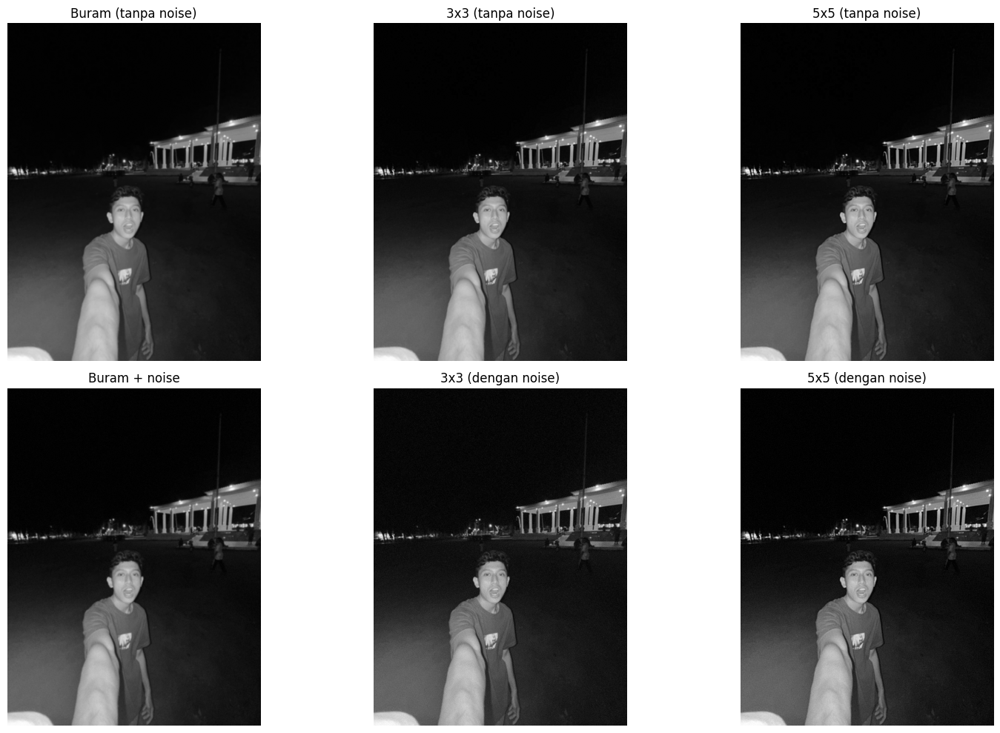

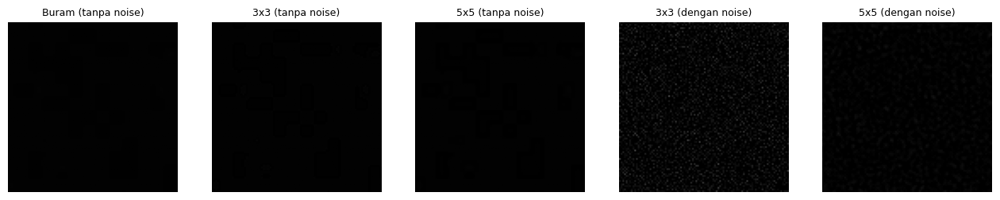

In [24]:
sharp_ref = gray                                                     # citra tajam (referensi)
blurry = cv.GaussianBlur(sharp_ref, (0, 0), 1.5)                     # citra sedikit buram

rng = np.random.default_rng(0)
noise = rng.normal(0, 4, blurry.shape)
blurry_noisy = to_uint8(blurry + noise)                              # buram + noise kamera ringan

def apply_sharp(image, k):
    return to_uint8(convolution2d(image, k, 1, k.shape[0] // 2, pad_mode='edge'))

res = {
    'Buram (tanpa noise)': blurry,
    '3x3 (tanpa noise)': apply_sharp(blurry, sharp3),
    '5x5 (tanpa noise)': apply_sharp(blurry, sharp5),
    'Buram + noise': blurry_noisy,
    '3x3 (dengan noise)': apply_sharp(blurry_noisy, sharp3),
    '5x5 (dengan noise)': apply_sharp(blurry_noisy, sharp5),
}
plt.figure(figsize=(16, 10))
for i, (n, im) in enumerate(res.items()):
    plt.subplot(2, 3, i + 1); plt.imshow(im, cmap='gray', vmin=0, vmax=255); plt.title(n); plt.axis('off')
plt.tight_layout(); plt.show()

# Zoom
y0, y1, x0, x1 = 100, 200, 220, 320
plt.figure(figsize=(16, 4.2))
for i, n in enumerate(['Buram (tanpa noise)', '3x3 (tanpa noise)', '5x5 (tanpa noise)', '3x3 (dengan noise)', '5x5 (dengan noise)']):
    plt.subplot(1, 5, i + 1); plt.imshow(res[n][y0:y1, x0:x1], cmap='gray', vmin=0, vmax=255); plt.title(n, fontsize=9); plt.axis('off')
plt.show()

**c. Evaluasi** – Kejelasan tepi (diukur dengan rata-rata magnitudo gradien Sobel dan varians Laplacian) dibandingkan dengan noise/distorsi (kenaikan simpangan baku noise setelah filter, dan PSNR terhadap citra tajam asli).

In [25]:
def sobel_mag(im):
    gx = cv.Sobel(im.astype(np.float64), cv.CV_64F, 1, 0, ksize=3)
    gy = cv.Sobel(im.astype(np.float64), cv.CV_64F, 0, 1, ksize=3)
    return np.hypot(gx, gy).mean()

def lap_var(im):
    return cv.Laplacian(im.astype(np.float64), cv.CV_64F).var()

def noise_std(k):
    # simpangan baku noise setelah difilter (selisih hasil filter pada citra bernoise vs tanpa noise)
    a = convolution2d(blurry_noisy, k, 1, k.shape[0] // 2, 'edge')
    b = convolution2d(blurry, k, 1, k.shape[0] // 2, 'edge')
    return (a - b).std()

rows = []
for n, im, k in [('Buram', blurry, None), ('Sharpen 3x3', res['3x3 (tanpa noise)'], sharp3), ('Sharpen 5x5', res['5x5 (tanpa noise)'], sharp5)]:
    ns = 4.0 if k is None else noise_std(k)
    noisy_ver = blurry_noisy if k is None else apply_sharp(blurry_noisy, k)
    rows.append((n, sobel_mag(im), lap_var(im), psnr(sharp_ref, im), ns, psnr(sharp_ref, noisy_ver)))

print(f'{"Citra":13s}{"Tepi (Sobel)":>14s}{"Var.Laplacian":>15s}{"PSNR bersih":>13s}{"Std noise":>11s}{"PSNR + noise":>14s}')
for r in rows:
    print(f'{r[0]:13s}{r[1]:14.1f}{r[2]:15.1f}{r[3]:13.2f}{r[4]:11.2f}{r[5]:14.2f}')

Citra          Tepi (Sobel)  Var.Laplacian  PSNR bersih  Std noise  PSNR + noise
Buram                  10.1            5.1        34.02       4.00         32.17
Sharpen 3x3            14.0           59.2        36.08      19.78         23.03
Sharpen 5x5            15.0           16.3        36.50       4.88         32.50


```markdown
**Kesimpulan Tugas 2** *(disesuaikan dengan angka keluaran sel di atas)*

| | Kejelasan tepi | Noise |
|---|---|---|
| **3x3** | Meningkat signifikan (Sobel 10.1 &rarr; 14.0, varians Laplacian 5.1 &rarr; 59.2). Tepi paling tajam pada detail sangat kecil, tetapi memunculkan efek kasar (*noise*) yang cukup terlihat. | Noise diperkuat secara signifikan (simpangan baku noise naik menjadi 19.78). PSNR dengan noise turun drastis menjadi 23.03 dB (gambar sangat berbintik). |
| **5x5** | Kejelasan tepi meningkat (Sobel 10.1 &rarr; 15.0, varians Laplacian 5.1 &rarr; 16.3). Efek penajaman terasa lebih halus dan merata karena mencakup area yang lebih luas. | Noise hanya meningkat sedikit (simpangan baku noise dari 4.00 naik menjadi hanya 4.88). PSNR dengan noise tetap terjaga tinggi di angka 32.50 dB. |

**Kernel yang paling optimal untuk penggunaan sehari-hari: 5x5.**
Foto sehari-hari hampir selalu mengandung noise (sensor, kompresi JPEG). Kernel 5x5 menundukkan dan menstabilkan peningkatan noise (hanya naik dari 4.00 menjadi 4.88) sambil tetap memberikan hasil penajaman tepi (Sobel naik menjadi 15.0) dengan PSNR yang jauh lebih sehat (32.50 dB vs 23.03 dB pada kernel 3x3). Ini karena struktur kernel 5x5 bertindak mirip band-pass filter yang membatasi penguatan frekuensi sangat tinggi (tempat noise berada).

Catatan:
- Kernel 3x3 tetap sangat berguna jika citra inputnya benar-benar bersih (*noise-free*) dan membutuhkan performa komputasi yang cepat.
```

### Tugas 3 – Kreasi: Filter Kartun Sederhana
Fungsi `kartun(image)`:
1. **Bilateral Filter** → area warna menjadi rata namun tepi tetap tajam,
2. **Adaptive Thresholding** (atau Canny) → garis tepi hitam,
3. **Penggabungan** → garis dikalikan dengan citra berwarna (`bitwise_and` dengan mask; ekuivalen dengan perkalian piksel oleh mask 0/1).

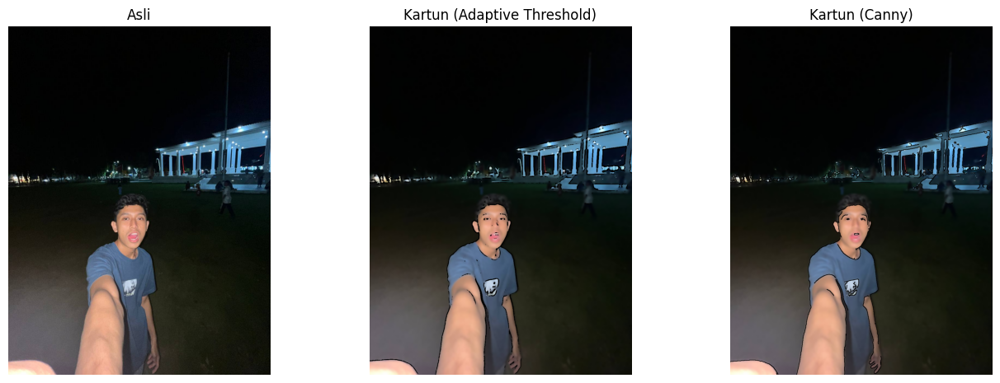

In [32]:
def kartun(image, metode_tepi='adaptive', jumlah_bilateral=2):
    """Filter kartun sederhana.
    image : citra BGR (uint8)
    metode_tepi : 'adaptive' (Adaptive Thresholding) atau 'canny'
    """
    # 1) Penghalusan warna dengan Bilateral Filter (diulang agar warna lebih rata)
    warna = image.copy()
    for _ in range(jumlah_bilateral):
        warna = cv.bilateralFilter(warna, d=9, sigmaColor=75, sigmaSpace=75)

    # 2) Deteksi garis tepi
    abu = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    abu = cv.medianBlur(abu, 7)                       # redam noise agar garis tidak "bintik-bintik"
    if metode_tepi == 'canny':
        tepi = cv.Canny(abu, 80, 160)
        tepi = cv.dilate(tepi, np.ones((2, 2), np.uint8))   # tebalkan garis
        mask = cv.bitwise_not(tepi)                  # garis = 0 (hitam), lainnya = 255
    else:
        mask = cv.adaptiveThreshold(abu, 255, cv.ADAPTIVE_THRESH_MEAN_C,
                                    cv.THRESH_BINARY, blockSize=9, C=9)   # garis = 0

    # 3) Gabungkan: warna x mask (garis menjadi hitam)
    mask3 = cv.cvtColor(mask, cv.COLOR_GRAY2BGR) // 255        # 0 / 1
    hasil = (warna * mask3).astype(np.uint8)
    return hasil

foto = load_image(BASE + '/fian.jpg', 'fian')
show_side_by_side([foto, kartun(foto), kartun(foto, 'canny')],
                  ['Asli', 'Kartun (Adaptive Threshold)', 'Kartun (Canny)'], figsize=(16, 5.5))

**b.** Citra asli dan citra efek kartun bersebelahan:

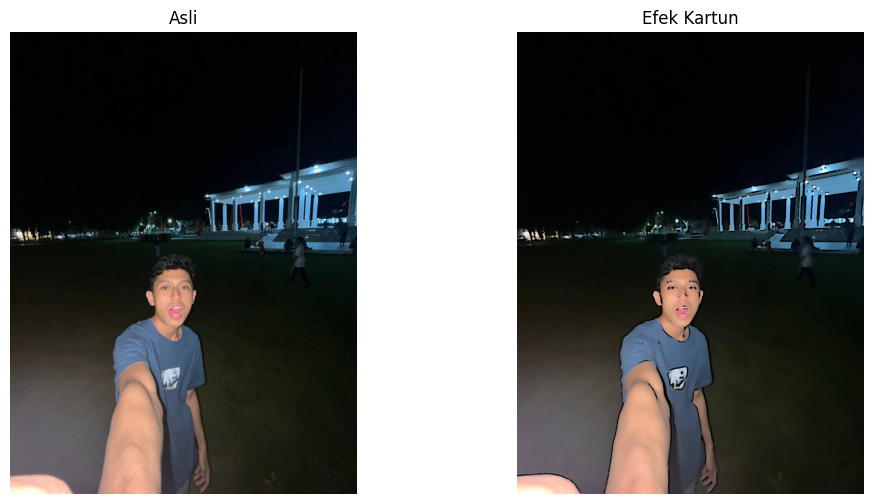

In [33]:
show_side_by_side([foto, kartun(foto)], ['Asli', 'Efek Kartun'], figsize=(12, 6))

**Catatan:** Adaptive Threshold menghasilkan garis lebih tebal dan detail (termasuk tekstur), sedangkan Canny menghasilkan garis lebih tipis dan bersih. Menambah `jumlah_bilateral` membuat warna makin rata (gaya kartun makin kuat), sedangkan `blockSize` dan `C` pada adaptive threshold mengatur ketebalan garis.